# Exploratory Data Analysis (EDA)

## Project
Netflix Content Analytics

## Sprint
Sprint 3 – Exploratory Data Analysis

## Objective

The objective of this notebook is to explore Netflix's content catalogue using the cleaned dataset and answer business questions that support strategic decision-making.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
file_path= '/content/drive/MyDrive/project_source_files/netflix_titles_cleaned.csv'
df= pd.read_csv(file_path)
df.head()


,Show Id,Type,Title,Director,Cast,Country,Date Added,Release Year,Rating,Duration,Listed In,Description
0,S1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25 00:00:00,2020,Pg-13,90 Min,Documentaries,"As Her Father Nears The End Of His Life, Filmm..."
1,S2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,Tv-Ma,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After Crossing Paths At A Party, A Cape Town T..."
2,S3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00,2021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To Protect His Family From A Powerful Drug Lor...
3,S4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24 00:00:00,2021,Tv-Ma,1 Season,"Docuseries, Reality Tv","Feuds, Flirtations And Toilet Talk Go Down Amo..."
4,S5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,Tv-Ma,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In A City Of Coaching Centers Known To Train I...


# Business Questions

The following questions will guide this exploratory analysis.

1. What percentage of Netflix's catalogue consists of Movies versus TV Shows?

2. How has Netflix's content library changed over time?

3. Which countries contribute the most content?

4. What are the most common content ratings?

5. Which genres dominate the catalogue?

6. What is the distribution of movie durations?

7. Which directors appear most frequently?

8. Which years produced the most content?

In [86]:
# Business Question 1:
# How many movies and TV shows are available on Netflix?
content_types = df["Type"].value_counts().reset_index(name="Number of Titles")
content_types

,Type,Number of Titles
0,Movie,6131
1,Tv Show,2676


/tmp/ipykernel_956/1779696431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=content_types, x="Type", y="Number of Titles", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


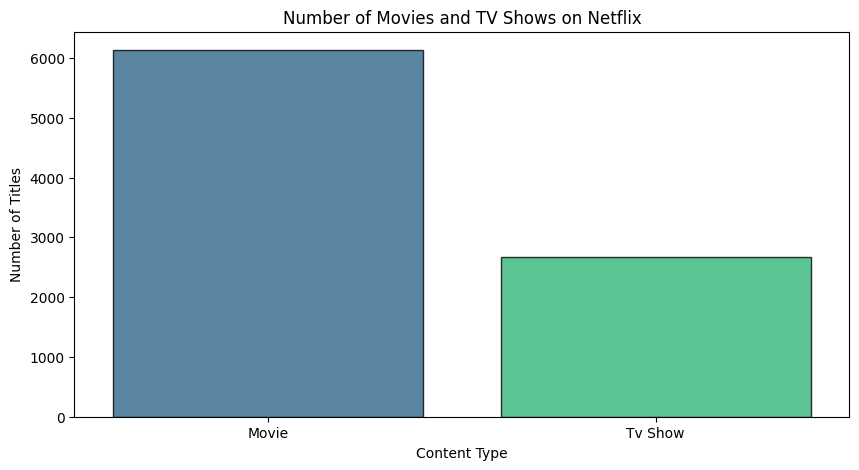

In [88]:
# Bar chart to visualize the number of movies and TV shows
plt.figure(figsize=(10,5))
sns.barplot(data=content_types, x="Type", y="Number of Titles", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Number of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.savefig('/content/drive/MyDrive/project_source_files/Movies_vs_TV_Shows.png', dpi=300, bbox_inches='tight')
plt.show()


### Business Insight

Movies account for approximately 70% of Netflix's catalogue, while TV Shows represent the remaining 30%. This indicates that movies make up the majority of the available content and remain a significant part of Netflix's library. However, this analysis reflects the dataset used for this project and should not be interpreted as Netflix's complete current catalogue.

In [89]:
# Calculate the percentage of each content type
content_types["Percentage"]= content_types["Number of Titles"]/content_types["Number of Titles"].sum()*100
content_types

,Type,Number of Titles,Percentage
0,Movie,6131,69.615079
1,Tv Show,2676,30.384921


In [90]:
# Business Question #2
# How has Netflix's content library changed over time?
df["Date Added"].head()


,Date Added
0,2021-09-25 00:00:00
1,2021-09-24 00:00:00
2,2021-09-24 00:00:00
3,2021-09-24 00:00:00
4,2021-09-24 00:00:00


In [91]:

# Drop rows with missing values in the "Date Added" column
df["Date Added"]=df["Date Added"].replace("Unknown", np.nan)
df=df.dropna(subset=["Date Added"])
df.isnull().sum()

,0
Show Id,0
Type,0
Title,0
Director,0
Cast,0
Country,0
Date Added,0
Release Year,0
Rating,0
Duration,0


In [92]:
# Extract the Year from the "Date Added" column and create a new column "Year Added"
df["Year Added"]= pd.to_datetime(df["Date Added"]).dt.year
df[["Date Added", "Year Added"]].head()

,Date Added,Year Added
0,2021-09-25 00:00:00,2021
1,2021-09-24 00:00:00,2021
2,2021-09-24 00:00:00,2021
3,2021-09-24 00:00:00,2021
4,2021-09-24 00:00:00,2021


In [93]:
# Count Contents Added Per Year
titles_per_year = df["Year Added"].value_counts().sort_index().reset_index(name="Number of Contents")
titles_per_year

,Year Added,Number of Contents
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


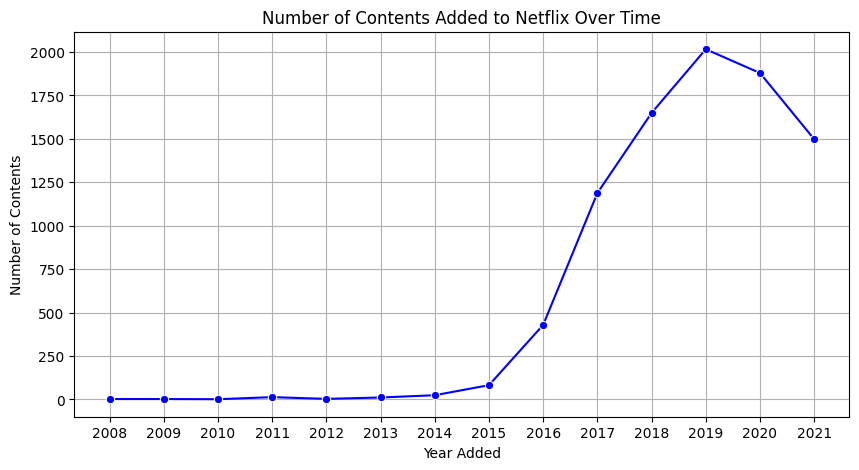

In [94]:
# plot the number of contents added to Netflix over time using a line chart
plt.figure(figsize=(10,5))
sns.lineplot(data=titles_per_year, x="Year Added", y="Number of Contents", marker="o", color="blue")
plt.title("Number of Contents Added to Netflix Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Contents")
plt.xticks(titles_per_year["Year Added"].unique())
plt.grid()
plt.savefig('/content/drive/MyDrive/project_source_files/Contents_added_overtime.png', dpi=300, bbox_inches='tight')
plt.show()

### Business Insight

The number of titles added to Netflix increased steadily over several years before reaching a peak and declining in later years. This trend may reflect changes in content acquisition strategies, licensing agreements, or production schedules. Additional business information would be required to determine the exact reasons for the decline.

In [95]:
# Business Question #3
# Which countries produce the most content for Netflix?
df["Country"].value_counts().head(20).reset_index(name="Number of Titles")

,Country,Number of Titles
0,United States,2812
1,India,972
2,Unknown,830
3,United Kingdom,418
4,Japan,244
5,South Korea,199
6,Canada,181
7,Spain,145
8,France,124
9,Mexico,110


In [96]:
# Split the "Country" column into a list of countries for each title 
# Explode the "Country" column to create a new row for each country associated with a title
country_df=df.copy()
country_df=df[df["Country"] != "Unknown"]
country_df["Country"] = country_df["Country"].str.split(",")
country_df = country_df.explode("Country")
country_df["Country"] = country_df["Country"].str.strip()  # Remove Extra Spaces


/tmp/ipykernel_956/1567470678.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_df["Country"] = country_df["Country"].str.split(",")


In [97]:
# Calculate the top 15 countries producing content for Netflix
top_countries=country_df["Country"].value_counts().head(15).reset_index(name="Number of Contents")
top_countries

,Country,Number of Contents
0,United States,3684
1,India,1046
2,United Kingdom,805
3,Canada,445
4,France,393
5,Japan,317
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


/tmp/ipykernel_956/4063301695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, y="Country", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


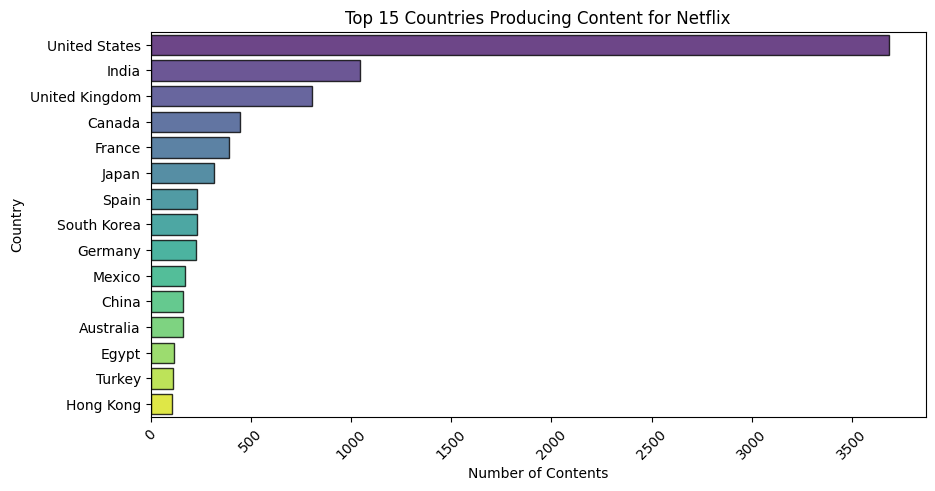

In [98]:
# Bar chart to visualize the top 15 countries producing content for Netflix
plt.figure(figsize=(10,5))
sns.barplot(data=top_countries, y="Country", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Top 15 Countries Producing Content for Netflix")
plt.xlabel("Number of Contents")
plt.ylabel("Country")
plt.xticks(rotation=45)
plt.savefig('/content/drive/MyDrive/project_source_files/Countries.png', dpi=300, bbox_inches='tight')
plt.show()

### Observation

The United States contributes the largest share of titles in the dataset, followed by India and the United Kingdom. This suggests that Netflix's catalogue relies heavily on content from a relatively small number of countries while still maintaining international diversity.

In [99]:
# Business Question #4
# What are the most common ratings for Netflix content?
df_ratings =df.copy()
df_ratings["Rating"]= df_ratings["Rating"].str.strip()
top_10_rating = df_ratings["Rating"].value_counts().head(10).reset_index(name="Number of Contents")
top_10_rating


,Rating,Number of Contents
0,Tv-Ma,3205
1,Tv-14,2157
2,Tv-Pg,861
3,R,799
4,Pg-13,490
5,Tv-Y7,333
6,Tv-Y,306
7,Pg,287
8,Tv-G,220
9,Nr,79


/tmp/ipykernel_956/1347378799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_rating, x="Rating", y="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


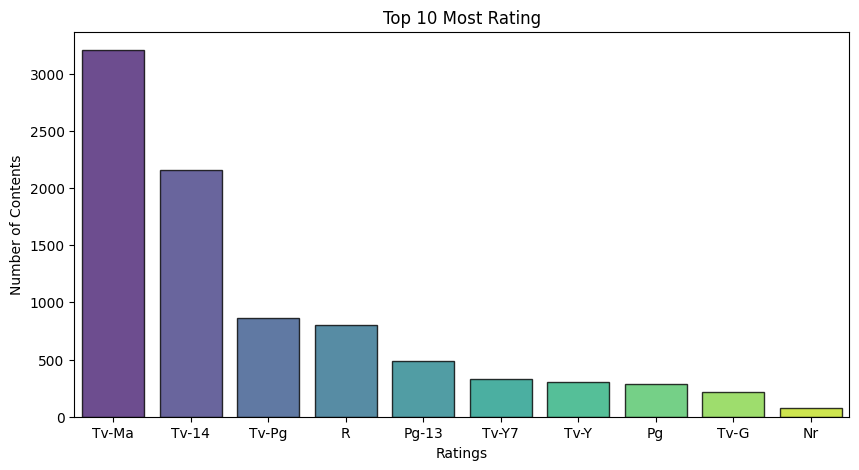

In [100]:
# plot the top 10 most common ratings using Bar Chart
plt.figure(figsize=(10,5))
sns.barplot(data=top_10_rating, x="Rating", y="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Top 10 Most Rating")
plt.xlabel("Ratings")
plt.ylabel("Number of Contents")
plt.savefig('/content/drive/MyDrive/project_source_files/Ratings.png', dpi=300, bbox_inches='tight')
plt.show()


### Observation

TV-MA and TV-14 are the most common content ratings in the dataset, indicating that a large portion of Netflix's catalogue is intended for mature and teenage audiences.

In [101]:
 # Business Question #5
# What are the most common Genres on Netflix?
genre_df=df.copy()
genre_df["Listed In"].head()

,Listed In
0,Documentaries
1,"International Tv Shows, Tv Dramas, Tv Mysteries"
2,"Crime Tv Shows, International Tv Shows, Tv Act..."
3,"Docuseries, Reality Tv"
4,"International Tv Shows, Romantic Tv Shows, Tv ..."


In [102]:
# spliting the "Listed In" column into individual genres and exploding it to create a new row for each genre
genre_df["Listed In"]= genre_df["Listed In"].str.split(",")
genre_df= genre_df.explode("Listed In")
genre_df["Listed In"]= genre_df["Listed In"].str.strip() # remove extra spaces
genre_df["Listed In"].head()



,Listed In
0,Documentaries
1,International Tv Shows
1,Tv Dramas
1,Tv Mysteries
2,Crime Tv Shows


In [103]:
# top 20 most common genres listed
top_genres= genre_df["Listed In"].value_counts().head(20).reset_index(name="Number of Contents")
top_genres

,Listed In,Number of Contents
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International Tv Shows,1350
4,Documentaries,869
5,Action & Adventure,859
6,Tv Dramas,762
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


/tmp/ipykernel_956/571409923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, y="Listed In", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


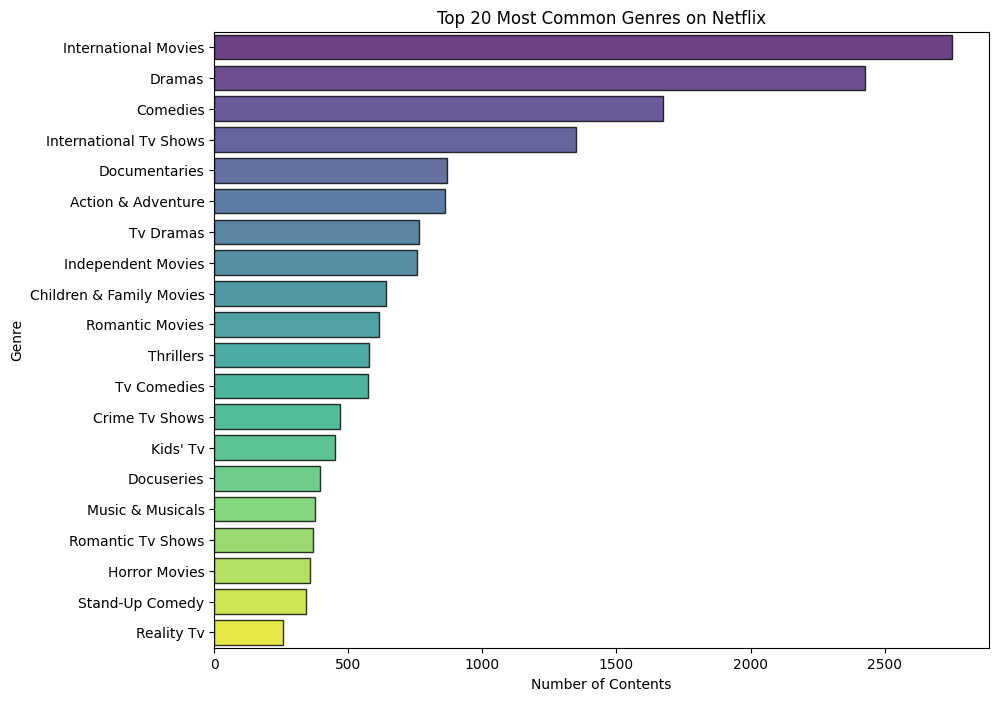

In [104]:
# plot the top 20 most common genres using a horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(data=top_genres, y="Listed In", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Top 20 Most Common Genres on Netflix")
plt.xlabel("Number of Contents")
plt.ylabel("Genre")
plt.savefig('/content/drive/MyDrive/project_source_files/Top_Genres.png', dpi=300, bbox_inches='tight')
plt.show()

### Observation

International Movies, Drama, and Comedy are among the most common genres in the catalogue. This suggests that Netflix offers a diverse selection of dramatic, comedic, and internationally produced content.

In [105]:
# Business Question #6
# What is the distribution of movie durations?
duration_df=df.copy()
duration_df[
"Duration"].head()

,Duration
0,90 Min
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons


In [106]:
 # Filter the DataFrame to include only movies
movies_df=duration_df[duration_df["Type"]=="Movie"]
movies_df[["Title","Type","Duration"]].head()

,Title,Type,Duration
0,Dick Johnson Is Dead,Movie,90 Min
6,My Little Pony: A New Generation,Movie,91 Min
7,Sankofa,Movie,125 Min
9,The Starling,Movie,104 Min
12,Je Suis Karl,Movie,127 Min


In [107]:
# Filter the DataFrame to include only TV show
tv_shows_df=duration_df[duration_df["Type"]=="Tv Show"]
tv_shows_df[["Title", "Type", "Duration"]].head()

,Title,Type,Duration
1,Blood & Water,Tv Show,2 Seasons
2,Ganglands,Tv Show,1 Season
3,Jailbirds New Orleans,Tv Show,1 Season
4,Kota Factory,Tv Show,2 Seasons
5,Midnight Mass,Tv Show,1 Season


In [108]:
# Cleaning the Duration Column and converting it to integer
# movies_df["Duration"]=movies_df["Duration"].str.replace(" Min", "")
movies_df["Duration"]= movies_df["Duration"].replace("Unknown", np.nan)
movies_df=movies_df.dropna(subset=["Duration"])
# Convert Duration to integer
movies_df["Duration"]=movies_df["Duration"].str.replace("Min", "").astype(int)
tv_shows_df["Duration"]=tv_shows_df["Duration"].str.replace("Seasons", "").str.replace("Season", "").str.replace("Episode", "").astype(int)


/tmp/ipykernel_956/3729546855.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_df["Duration"]= movies_df["Duration"].replace("Unknown", np.nan)
/tmp/ipykernel_956/3729546855.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_shows_df["Duration"]=tv_shows_df["Duration"].str.replace("Seasons", "").str.replace("Season", "").str.replace("Episode", "").astype(int)


In [109]:
# grouping data by the Duration and count them
movies_duration=movies_df["Duration"].value_counts().reset_index(name="Number of Movies").sort_index()
movies_duration.head(10)

,Duration,Number of Movies
0,90,152
1,97,146
2,94,146
3,93,146
4,91,144
5,95,137
6,96,130
7,92,129
8,102,122
9,98,120


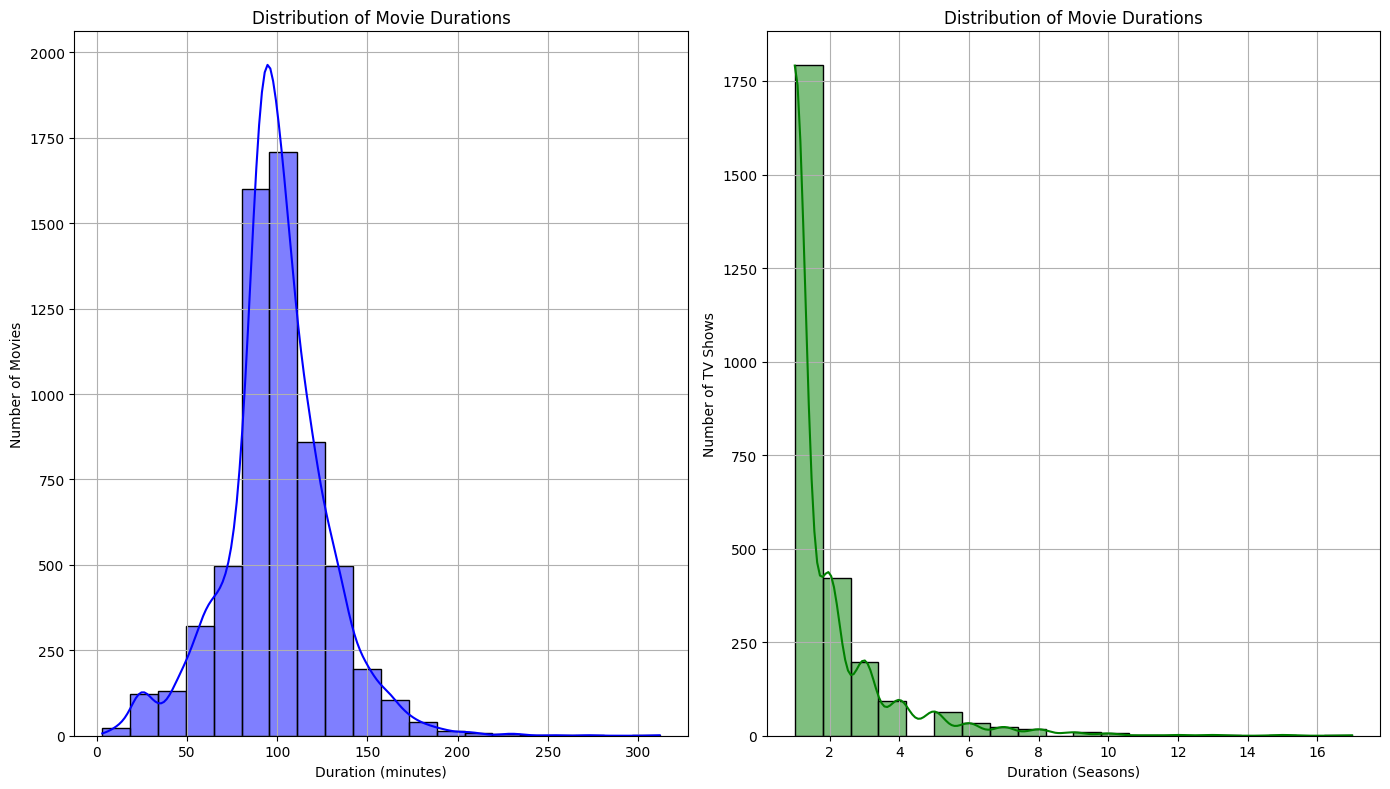

In [110]:
# plot the distribution of movie and TV shows durations using a two plots in the same axis

fig=plt.figure(figsize=(14, 8))
ax0=fig.add_subplot(1,2,1)
ax1=fig.add_subplot(1, 2, 2)
# Plot for Movie Duration
sns.histplot(movies_df["Duration"], bins=20, kde=True, ax=ax0, color="blue")
ax0.set_title("Distribution of Movie Durations")
ax0.set_xlabel("Duration (minutes)")
ax0.set_ylabel("Number of Movies")
plt.tight_layout()
ax0.grid(True)

# Plot for TV Shows Duration
sns.histplot(tv_shows_df["Duration"], bins=20, kde=True, ax=ax1, color="green")
ax1.set_title("Distribution of Movie Durations")
ax1.set_xlabel("Duration (Seasons)")
ax1.set_ylabel("Number of TV Shows")
plt.tight_layout()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/project_source_files/Movies_and_TV_shows_duration.png')
plt.show()


### Observation 1

- Most Netflix movies fall within the 80–120 minute range, indicating that feature-length films dominate the catalogue.

### Observation 2

- Among TV Shows, a single season is the most common format, suggesting that limited-series or newly introduced series make up a substantial portion of the television catalogue.

In [111]:
# Business Question #7
# Who are the most frequent Directors on Netflix?
director_df=df.copy()
director_df= director_df[director_df["Director"]!= "Unknown"]       # Filter the DataFrame to exclude rows where the Director is "Unknown"
director_df["Director"]= director_df["Director"].str.split(", ")      # Split the "Director" column into a list of directors
director_df= director_df.explode("Director")        # Explode the "Director" column to create a new row for each director
director_df["Director"]= director_df["Director"].str.strip()        # Remove extra spaces
top_directors= director_df["Director"].value_counts().head(15).reset_index(name="Number of Contents")     # Calculate the top 15 most frequent directors
top_directors

,Director,Number of Contents
0,Rajiv Chilaka,22
1,Jan Suter,21
2,Raúl Campos,19
3,Suhas Kadav,16
4,Marcus Raboy,16
5,Jay Karas,15
6,Cathy Garcia-Molina,13
7,Jay Chapman,12
8,Youssef Chahine,12
9,Martin Scorsese,12


/tmp/ipykernel_956/2441148564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_directors, y="Director", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


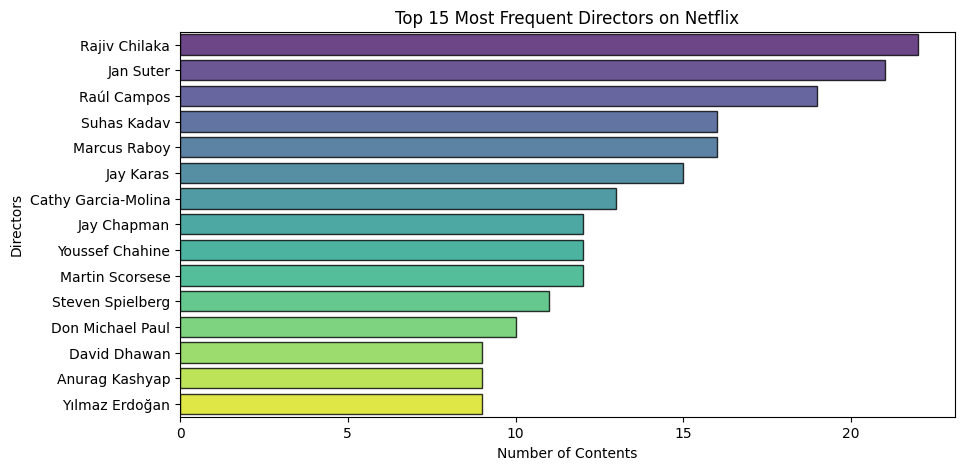

In [ ]:
# Bar chart to visualize the top 15 most frequent directors on Netflix
plt.figure(figsize=(10, 5))
sns.barplot(data=top_directors, y="Director", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Top 15 Most Frequent Directors on Netflix")
plt.xlabel("Number of Contents")
plt.ylabel("Directors")
plt.show()

### Observation

The directors with the highest number of titles each contribute approximately 10–20 titles within this dataset. These counts represent only the titles included in the analysed Netflix catalogue and should not be interpreted as each director's complete body of work.